In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import LabelEncoder

In [2]:
# 데이터 불러오기
df = pd.read_csv('../data/무_월차낼게요.csv', encoding='cp949')
df_grow = pd.read_csv('../data/factor_external_weekly_ver_0721.csv', encoding='utf-8')

In [3]:
df['총거래량(kg)'] = np.log1p(df['총거래량(kg)'])

In [4]:
df.head()


,year,week,week_start,품종코드,등급코드,직팜산지코드,총거래량(kg),일평균기온,최고기온,최저기온,...,최저기온_t-2,평균상대습도_t-2,강수량(mm)_t-2,1시간최고강수량(mm)_t-2,일평균기온_t-3,최고기온_t-3,최저기온_t-3,평균상대습도_t-3,강수량(mm)_t-3,1시간최고강수량(mm)_t-3
0,2018,13,2018-03-26,100,11,1079,7.365813,16.800000,24.1,12.3,...,-6.550,52.208333,1.050,0.0,-0.685417,5.000,-5.525,72.120833,5.300,0.0
1,2018,13,2018-03-26,100,11,1137,9.261129,13.600000,17.6,9.4,...,0.975,62.008333,1.375,0.0,7.069048,12.675,3.300,71.919048,9.900,0.0
2,2018,13,2018-03-26,100,11,1170,6.398595,15.600000,19.3,12.0,...,0.550,57.207500,3.500,0.0,6.950000,11.250,3.175,69.987500,7.400,0.0
3,2018,13,2018-03-26,100,12,1000,8.692994,11.000000,18.1,5.3,...,-9.575,54.875000,1.750,0.0,-3.384821,3.275,-7.000,52.450893,1.050,0.0
4,2018,13,2018-03-26,100,12,1079,7.090910,14.333333,23.4,7.0,...,-5.875,55.605000,0.200,0.0,1.635000,7.225,-3.075,69.767500,8.275,0.0


In [5]:
# year, week 파생
def format_week_int(weekno):
    year = weekno // 100
    week = weekno % 100
    return year, week

df_grow[['year', 'week']] = df_grow['weekno'].apply(lambda x: pd.Series(format_week_int(x)))
df_grow.drop(columns='weekno', inplace=True)

# 병합 전 품목코드 추가
df['item_code'] = 1101

# 외생변수 병합
df = pd.merge(
    df,
    df_grow[['year', 'week', 'item_code', 'holiday_flag', 'holiday_score', 'grow_score']],
    on=['year', 'week', 'item_code'],
    how='left'
)

# 병합 후 외생변수 컬럼 재정의
for col in ['holiday_flag', 'holiday_score', 'grow_score']:
    if f"{col}_y" in df.columns:
        df[col] = df[f"{col}_y"]
        df.drop(columns=[f"{col}_x", f"{col}_y"], inplace=True)
df.drop(columns='item_code', inplace=True)

In [6]:
df.columns

Index(['year', 'week', 'week_start', '품종코드', '등급코드', '직팜산지코드', '총거래량(kg)',
       '일평균기온', '최고기온', '최저기온', '평균상대습도', '강수량(mm)', '1시간최고강수량(mm)', '평균단가(원)',
       '일평균기온_t-1', '최고기온_t-1', '최저기온_t-1', '평균상대습도_t-1', '강수량(mm)_t-1',
       '1시간최고강수량(mm)_t-1', '일평균기온_t-2', '최고기온_t-2', '최저기온_t-2', '평균상대습도_t-2',
       '강수량(mm)_t-2', '1시간최고강수량(mm)_t-2', '일평균기온_t-3', '최고기온_t-3', '최저기온_t-3',
       '평균상대습도_t-3', '강수량(mm)_t-3', '1시간최고강수량(mm)_t-3', 'holiday_flag',
       'holiday_score', 'grow_score'],
      dtype='object')

In [7]:
# 불필요 컬럼 제거
# df = df.drop(columns=['등급코드', '일평균기온', '최고기온', '최저기온', '평균상대습도', '강수량(mm)', '1시간최고강수량(mm)'], errors='ignore')

In [8]:
# 0. 최소 연도 확인 (예: 2018)
min_year = df['year'].min()

# 1. 병합 대상 테이블 생성 (중복 제거 중요!)
price_lag = (
    df[['year', 'week', '직팜산지코드', '품종코드', '평균단가(원)']]
    .drop_duplicates(subset=['year', 'week', '직팜산지코드', '품종코드'])
    .copy()
)
price_lag['year'] += 1
price_lag = price_lag.rename(columns={'평균단가(원)': 'price_lag_1y'})

# 2. 병합 수행 (1:1 보장)
df = pd.merge(
    df,
    price_lag,
    on=['year', 'week', '직팜산지코드', '품종코드'],
    how='left'
)

# 3. 월 기준 평균단가로 보완
df['month'] = pd.to_datetime(df['week_start']).dt.month

monthly_avg = (
    df[['year', 'month', '직팜산지코드', '품종코드', '평균단가(원)']]
    .groupby(['year', 'month', '직팜산지코드', '품종코드'], as_index=False)
    .mean()
)

monthly_avg['year'] += 1
monthly_avg = monthly_avg.rename(columns={'평균단가(원)': 'price_lag_month_fill'})

df = pd.merge(
    df,
    monthly_avg,
    on=['year', 'month', '직팜산지코드', '품종코드'],
    how='left'
)

# 📌 월평균으로 보완 (단, 최소 연도는 제외)
df['price_lag_1y'] = df.apply(
    lambda row: row['price_lag_month_fill']
    if pd.isna(row['price_lag_1y']) and row['year'] > min_year
    else row['price_lag_1y'],
    axis=1
)

# 4. 연 평균으로 fallback
yearly_avg = (
    df[['year', '직팜산지코드', '품종코드', '평균단가(원)']]
    .groupby(['year', '직팜산지코드', '품종코드'], as_index=False)
    .mean()
)
yearly_avg['year'] += 1
yearly_avg = yearly_avg.rename(columns={'평균단가(원)': 'price_lag_fallback'})

df = pd.merge(
    df,
    yearly_avg,
    on=['year', '직팜산지코드', '품종코드'],
    how='left'
)

df['price_lag_1y'] = df.apply(
    lambda row: row['price_lag_fallback']
    if pd.isna(row['price_lag_1y']) and row['year'] > min_year
    else row['price_lag_1y'],
    axis=1
)
df.dropna(subset=['price_lag_1y'], inplace=True)

In [9]:
print("병합 후 행 수:", len(df))
print("NaN 비율:", df['price_lag_1y'].isna().mean())

병합 후 행 수: 74775
NaN 비율: 0.0


In [10]:
# df.drop(columns=['month', 'price_lag_month_fill', 'price_lag_fallback'], inplace=True, errors='ignore')

df.sample(5)

,year,week,week_start,품종코드,등급코드,직팜산지코드,총거래량(kg),일평균기온,최고기온,최저기온,...,평균상대습도_t-3,강수량(mm)_t-3,1시간최고강수량(mm)_t-3,holiday_flag,holiday_score,grow_score,price_lag_1y,month,price_lag_month_fill,price_lag_fallback
72929,2024,3,2024-01-15,100,11,1170,6.985642,6.10,8.7,4.5,...,71.921875,36.450,13.300,2,0.0,15,548.00000,1,444.958333,505.430556
73110,2024,5,2024-01-29,1,12,1000,7.766841,3.90,10.6,0.7,...,63.845833,2.175,0.000,2,2.5,21,572.02439,1,NaN,572.024390
27851,2020,23,2020-06-01,99,12,1111,11.106775,21.32,30.9,11.1,...,59.215000,3.450,0.000,2,0.0,14,363.00000,6,395.625000,468.494949
52443,2022,26,2022-06-27,100,12,1120,4.110874,28.20,33.4,23.6,...,65.333333,5.375,2.225,2,0.0,21,226.25000,6,NaN,226.250000
63784,2023,22,2023-05-29,100,12,1131,9.672879,18.60,25.3,15.8,...,58.552500,0.000,0.000,3,0.0,8,1365.80000,5,NaN,1365.800000


In [11]:
print("남은 컬럼:\n", df.columns.tolist())


남은 컬럼:
 ['year', 'week', 'week_start', '품종코드', '등급코드', '직팜산지코드', '총거래량(kg)', '일평균기온', '최고기온', '최저기온', '평균상대습도', '강수량(mm)', '1시간최고강수량(mm)', '평균단가(원)', '일평균기온_t-1', '최고기온_t-1', '최저기온_t-1', '평균상대습도_t-1', '강수량(mm)_t-1', '1시간최고강수량(mm)_t-1', '일평균기온_t-2', '최고기온_t-2', '최저기온_t-2', '평균상대습도_t-2', '강수량(mm)_t-2', '1시간최고강수량(mm)_t-2', '일평균기온_t-3', '최고기온_t-3', '최저기온_t-3', '평균상대습도_t-3', '강수량(mm)_t-3', '1시간최고강수량(mm)_t-3', 'holiday_flag', 'holiday_score', 'grow_score', 'price_lag_1y', 'month', 'price_lag_month_fill', 'price_lag_fallback']


In [12]:
# y, X 분리
y = df['평균단가(원)']
X = df.drop(columns=['평균단가(원)'])

In [13]:
def generate_moving_averages_fixed(df, target_col='평균단가(원)', group_cols=['직팜산지코드', '품종코드'], windows=[4, 13, 26]):
    """
    데이터 누수를 방지하고 이동평균 피처를 생성하는 수정된 함수
    """
    df = df.sort_values(group_cols + ['year', 'week']).copy()

    # 1. 그룹별로 target 값을 shift하여 임시 컬럼 생성 (데이터 누수 방지)
    df['shifted_target'] = df.groupby(group_cols)[target_col].shift(1)

    # 2. shift된 컬럼을 기준으로 이동 통계 피처 계산
    for w in windows:
        df[f'SMA_{w}'] = df.groupby(group_cols)['shifted_target'].transform(
            lambda x: x.rolling(window=w, min_periods=1).mean()
        )
        df[f'EMA_{w}'] = df.groupby(group_cols)['shifted_target'].transform(
            lambda x: x.ewm(span=w, adjust=False).mean()
        )

    # 3. 위에서 계산된 EMA 피처를 기반으로 파생 변수 생성
    df['EMA4_SMA4_diff'] = df['EMA_4'] - df['SMA_4']
    df['EMA13_SMA13_diff'] = df['EMA_13'] - df['SMA_13']
    df['EMA26_SMA26_diff'] = df['EMA_26'] - df['SMA_26']

    df['EMA_4_rate'] = df.groupby(group_cols)['EMA_4'].transform(lambda x: x.pct_change().fillna(0))
    df['EMA_13_rate'] = df.groupby(group_cols)['EMA_13'].transform(lambda x: x.pct_change().fillna(0))
    df['EMA_26_rate'] = df.groupby(group_cols)['EMA_26'].transform(lambda x: x.pct_change().fillna(0))

    # 4. 임시로 사용한 컬럼 제거
    df = df.drop(columns=['shifted_target'])

    return df

# 수정된 함수를 호출합니다.
df_fixed = generate_moving_averages_fixed(df)

moving_avg_cols = [
    'SMA_4', 'SMA_13', 'SMA_26',
    'EMA_4', 'EMA_13', 'EMA_26',
    'EMA4_SMA4_diff', 'EMA13_SMA13_diff', 'EMA26_SMA26_diff',
    'EMA_4_rate', 'EMA_13_rate', 'EMA_26_rate', 'holiday_flag',
    'holiday_score', 'grow_score', 'price_lag_1y'
]

# df_final 이라는 새 변수에 결측값이 제거된 최종 데이터를 저장
df = df_fixed.dropna(subset=moving_avg_cols).copy()

# 1. 단기 시차(Lag) 피처 추가
print("단기 시차 피처를 추가합니다...")

# 그룹별(산지-품종)로 이전 1주, 2주, 3주차의 단가를 가져옵니다.
group_cols = ['직팜산지코드', '품종코드']
lags = [1, 2, 3]

for lag in lags:
    col_name = f'price_lag_{lag}w' # 컬럼 이름 예: price_lag_1w
    df[col_name] = df.groupby(group_cols)['평균단가(원)'].shift(lag)
    print(f"'{col_name}' 피처 생성 완료.")

# 2. 시차 피처 생성 후 생긴 결측값(NaN) 처리
# 각 그룹의 맨 앞부분에는 이전 데이터가 없어 NaN이 발생합니다.
# 이 행들은 모델 학습에 사용할 수 없으므로 제거합니다.
print("\\n시차 피처 생성으로 인해 발생한 결측값을 제거합니다...")
original_rows = len(df)
df.dropna(inplace=True) # 모든 NaN을 가진 행을 제거
new_rows = len(df)
print(f"{original_rows - new_rows}개의 행이 제거되었습니다.")

# 3. 추가된 피처 확인
print("\n추가된 시차 피처 확인:")
print(df[['year', 'week', '평균단가(원)', 'price_lag_1w', 'price_lag_2w', 'price_lag_3w']].head())


C:\Users\Admin\AppData\Local\Temp\ipykernel_9560\232601529.py:24: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['EMA_4_rate'] = df.groupby(group_cols)['EMA_4'].transform(lambda x: x.pct_change().fillna(0))
C:\Users\Admin\AppData\Local\Temp\ipykernel_9560\232601529.py:25: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['EMA_13_rate'] = df.groupby(group_cols)['EMA_13'].transform(lambda x: x.pct_change().fillna(0))
C:\Users\Admin\AppData\Local\Temp\ipykernel_9560\232601529.py:26: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future vers

단기 시차 피처를 추가합니다...
'price_lag_1w' 피처 생성 완료.
'price_lag_2w' 피처 생성 완료.
'price_lag_3w' 피처 생성 완료.
\n시차 피처 생성으로 인해 발생한 결측값을 제거합니다...
11620개의 행이 제거되었습니다.

추가된 시차 피처 확인:
       year  week  평균단가(원)  price_lag_1w  price_lag_2w  price_lag_3w
12108  2019    18    655.0         516.0         554.0         509.0
12115  2019    18    386.0         655.0         516.0         554.0
12258  2019    19    516.0         386.0         655.0         516.0
12269  2019    19    455.0         516.0         386.0         655.0
12447  2019    20    478.0         455.0         516.0         386.0


In [14]:

# 4주간의 가격 변동성(표준편차) 피처 생성
df['price_roll_std_4w'] = df.groupby(['직팜산지코드', '품종코드'])['price_lag_1w'].transform(
    lambda x: x.rolling(window=4, min_periods=1).std()
)

# 결측값 처리
df.fillna(0, inplace=True)

In [15]:
# 모델 학습용 재분리 및 주기형 변수 처리
y = df['평균단가(원)']
X = df.drop(columns=['평균단가(원)'])

# ✅ 여기서 제거하는 게 베스트!
X = X.drop(columns=[
    '등급코드', '일평균기온', '최고기온', '최저기온',
    '평균상대습도', '강수량(mm)', '1시간최고강수량(mm)',
    'month', 'price_lag_month_fill', 'price_lag_fallback'
], errors='ignore')

X['week_start'] = pd.to_datetime(X['week_start'])
X['year'] = X['week_start'].dt.year
X['week'] = X['week_start'].dt.isocalendar().week.astype(int)

X['week_sin'] = np.sin(2 * np.pi * X['week'] / 52)
X['week_cos'] = np.cos(2 * np.pi * X['week'] / 52)
X = X.drop(columns=['week'])


In [16]:
X_train = X[X['year'] < 2025].drop(columns=['week_start'])
y_train = y[X['year'] < 2025]
X_test = X[X['year'] == 2025].drop(columns=['week_start'])
y_test = y[X['year'] == 2025]


In [17]:
from sklearn.preprocessing import RobustScaler

exclude_cols = ['year', '품종코드', '직팜산지코드']  # 범주형 및 예외
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
scale_cols = [col for col in numerical_cols if col not in exclude_cols]

scaler = RobustScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

In [18]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['직팜산지코드', '품종코드']

for col in cat_cols:
    le = LabelEncoder()
    # 훈련 데이터로 인코더 학습 및 변환
    X_train[col] = le.fit_transform(X_train[col])
    
    # 딕셔너리를 사용해 알려진 라벨만 매핑하는 mapping 생성
    mapping = {label: i for i, label in enumerate(le.classes_)}
    
    # 시험 데이터 변환:
    # .map(mapping) -> 알려진 라벨은 숫자로 변환하고, 모르는 라벨(unseen)은 NaN으로 만듦
    # .fillna(-1)   -> NaN으로 바뀐 모르는 라벨들을 -1로 채움
    X_test[col] = X_test[col].map(mapping).fillna(-1).astype(int)

    print(f"'{col}' 인코딩 완료. 테스트 데이터의 새로운 라벨은 -1로 처리되었습니다.")

'직팜산지코드' 인코딩 완료. 테스트 데이터의 새로운 라벨은 -1로 처리되었습니다.
'품종코드' 인코딩 완료. 테스트 데이터의 새로운 라벨은 -1로 처리되었습니다.


In [19]:
# df.sample(5)
X_train.isna().sum(), X_test.isna().sum()
# train_df.info()
# test_df.info()

(year                 0
 품종코드                 0
 직팜산지코드               0
 총거래량(kg)             0
 일평균기온_t-1            0
 최고기온_t-1             0
 최저기온_t-1             0
 평균상대습도_t-1           0
 강수량(mm)_t-1          0
 1시간최고강수량(mm)_t-1     0
 일평균기온_t-2            0
 최고기온_t-2             0
 최저기온_t-2             0
 평균상대습도_t-2           0
 강수량(mm)_t-2          0
 1시간최고강수량(mm)_t-2     0
 일평균기온_t-3            0
 최고기온_t-3             0
 최저기온_t-3             0
 평균상대습도_t-3           0
 강수량(mm)_t-3          0
 1시간최고강수량(mm)_t-3     0
 holiday_flag         0
 holiday_score        0
 grow_score           0
 price_lag_1y         0
 SMA_4                0
 EMA_4                0
 SMA_13               0
 EMA_13               0
 SMA_26               0
 EMA_26               0
 EMA4_SMA4_diff       0
 EMA13_SMA13_diff     0
 EMA26_SMA26_diff     0
 EMA_4_rate           0
 EMA_13_rate          0
 EMA_26_rate          0
 price_lag_1w         0
 price_lag_2w         0
 price_lag_3w         0
 price_roll_std_

In [20]:
# 1. Optuna 라이브러리 설치 (최초 1회만 실행)
# !pip install optuna

import optuna
from lightgbm import LGBMRegressor
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer, mean_squared_error
import numpy as np

# ---------------------------------------------------------------------------

# 2. 최적화 목표(Objective) 함수 정의
def objective(trial):
    """Optuna가 최적의 하이퍼파라미터를 찾기 위해 호출하는 함수"""
    
    # 탐색할 하이퍼파라미터 범위 지정 (정수, 실수, 카테고리 등)
    # learning_rate는 log 스케일로 탐색하는 것이 일반적입니다.
    params = {
        'objective': 'regression_l1', # MAE를 목적 함수로 설정하여 이상치에 덜 민감하게 만듦
        'metric': 'rmse',
        'random_state': 42,
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 5, 16),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-2, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-2, 10.0, log=True),
        'n_jobs': -1
    }
    
    # 모델 생성
    model = LGBMRegressor(**params)
    
    # 교차 검증을 통해 모델의 성능(RMSE)을 강건하게 평가
    # RMSE는 낮을수록 좋으므로, 음수 RMSE 값의 평균을 사용
    rmse_scorer = make_scorer(lambda y, y_pred: -np.sqrt(mean_squared_error(y, y_pred)))
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring=rmse_scorer)
    
    return scores.mean()

# ---------------------------------------------------------------------------

# 3. Optuna Study 생성 및 최적화 실행
# Pruner: 성능이 좋지 않은 trial을 조기에 중단시켜 시간을 절약
pruner = optuna.pruners.MedianPruner(n_warmup_steps=5)
# direction: neg_root_mean_squared_error는 음수이므로, 값이 클수록(0에 가까울수록) 좋기 때문에 'maximize'로 설정
study = optuna.create_study(direction='maximize', pruner=pruner)

# n_trials: 총 시도 횟수. 50~100회 정도가 적당합니다.
study.optimize(objective, n_trials=100)

# ---------------------------------------------------------------------------

# 4. 최적 결과 확인
print("탐색 완료!")
print(f"총 시도 횟수: {len(study.trials)}")
print("최적의 하이퍼파라미터:", study.best_params)
print(f"최적의 RMSE 값: {-study.best_value:.4f}") # 음수였던 점수를 양수로 변환

# ---------------------------------------------------------------------------

# 5. 최적의 하이퍼파라미터로 최종 모델 학습 및 예측
best_params = study.best_params
model = LGBMRegressor(**best_params, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
pred = model.predict(X_test)

# ... 이후 성능 평가 및 시각화 코드는 동일하게 진행 ...

c:\Users\Admin\anaconda3\envs\ten\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2025-07-24 17:04:01,315] A new study created in memory with name: no-name-684943ad-4f3c-4340-853e-603577b5ebdc


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006861 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9426
[LightGBM] [Info] Number of data points in the train set: 40216, number of used features: 44
[LightGBM] [Info] Start training from score 451.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

[I 2025-07-24 17:04:22,988] Trial 0 finished with value: -228.36612635940813 and parameters: {'n_estimators': 610, 'learning_rate': 0.006472871591634227, 'max_depth': 8, 'num_leaves': 85, 'min_child_samples': 50, 'subsample': 0.6469879217133606, 'colsample_bytree': 0.7665560580527571, 'reg_alpha': 0.012089720736880123, 'reg_lambda': 0.2034108071656222}. Best is trial 0 with value: -228.36612635940813.


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013706 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9426
[LightGBM] [Info] Number of data points in the train set: 40216, number of used features: 44
[LightGBM] [Info] Start training from score 451.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

[I 2025-07-24 17:04:58,686] Trial 1 finished with value: -217.78118001692602 and parameters: {'n_estimators': 682, 'learning_rate': 0.03027315311456182, 'max_depth': 15, 'num_leaves': 88, 'min_child_samples': 78, 'subsample': 0.6482656739769734, 'colsample_bytree': 0.9193532774351003, 'reg_alpha': 0.19656752534717833, 'reg_lambda': 0.3206276924577102}. Best is trial 1 with value: -217.78118001692602.


...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008669 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9426
[LightGBM] [Info] Number of data points in the train set: 40216, number of used features: 44
[LightGBM] [Info] Start training from score 451.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009691 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9435
[LightGBM] [Info] Number of data points in the train set: 40217, number of used features: 44
[LightGBM] [Info] Start training from score 461.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0

[I 2025-07-24 18:06:52,751] Trial 77 finished with value: -215.03917191416713 and parameters: {'n_estimators': 1878, 'learning_rate': 0.03632370603234799, 'max_depth': 15, 'num_leaves': 77, 'min_child_samples': 94, 'subsample': 0.8822783295113612, 'colsample_bytree': 0.8603454093620148, 'reg_alpha': 8.086665117269996, 'reg_lambda': 4.476785445192187}. Best is trial 73 with value: -214.35153361514813.


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010563 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9426
[LightGBM] [Info] Number of data points in the train set: 40216, number of used features: 44
[LightGBM] [Info] Start training from score 451.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

[W 2025-07-24 18:08:10,409] Trial 78 failed with parameters: {'n_estimators': 1936, 'learning_rate': 0.06054445327719786, 'max_depth': 14, 'num_leaves': 91, 'min_child_samples': 91, 'subsample': 0.8209998581985128, 'colsample_bytree': 0.9187897496476143, 'reg_alpha': 6.639275506128415, 'reg_lambda': 7.695536410422376} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\Admin\anaconda3\envs\ten\lib\site-packages\optuna\study\_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\Admin\AppData\Local\Temp\ipykernel_9560\1081909782.py", line 40, in objective
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring=rmse_scorer)
  File "c:\Users\Admin\anaconda3\envs\ten\lib\site-packages\sklearn\utils\_param_validation.py", line 218, in wrapper
    return func(*args, **kwargs)
  File "c:\Users\Admin\anaconda3\envs\ten\lib\site-packages\sklearn\model_selection\_validation.py", line 677, in cross

KeyboardInterrupt: 

In [ ]:
# ✅ 성능 지표 계산
rmse = np.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)
mape = mean_absolute_percentage_error(y_test, pred) * 100  # %

r2 = r2_score(y_test, pred)

# ✅ 출력
print("\n🏁 모델 성능:")
print(f"📉 RMSE: {rmse:.2f}")
print(f"📊 MAE : {mae:.2f}")
print(f"📊 MAPE: {mape:.2f}%")
print(f"📈 R²   : {r2:.4f}")


🏁 모델 성능:
📉 RMSE: 355.81
📊 MAE : 289.49
📊 MAPE: 42.25%
📈 R²   : 0.1574


In [ ]:
# 중요도 추출
importances = model.feature_importances_
feature_names = X_train.columns

# Series로 보기 좋게
import pandas as pd
feat_importance = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# 출력
print("\n🔍 변수 중요도 Top 10")
print(feat_importance.head(10))


🔍 변수 중요도 Top 10
총거래량(kg)        1320
price_lag_2w    1091
week_sin        1047
직팜산지코드           999
year             994
강수량(mm)_t-2      985
week_cos         976
강수량(mm)_t-1      961
price_lag_1w     942
강수량(mm)_t-3      932
dtype: int32


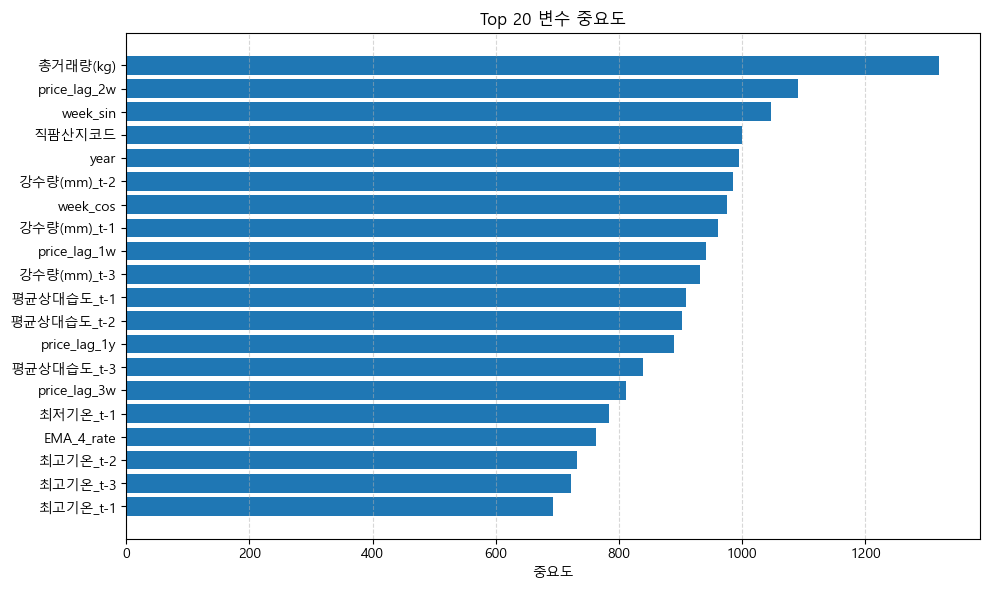

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# ✅ 1. 변수 중요도 추출 (Gain 기준)

importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_  # ✅ LightGBM이든 RF든 OK
}).sort_values("importance", ascending=False).reset_index(drop=True)

# 시각화
top_n = 20
plt.figure(figsize=(10, 6))
plt.barh(importance_df["feature"][:top_n][::-1], importance_df["importance"][:top_n][::-1])
plt.xlabel("중요도")
plt.title(f"Top {top_n} 변수 중요도")
plt.tight_layout()
plt.grid(True, axis="x", linestyle="--", alpha=0.5)
plt.show()


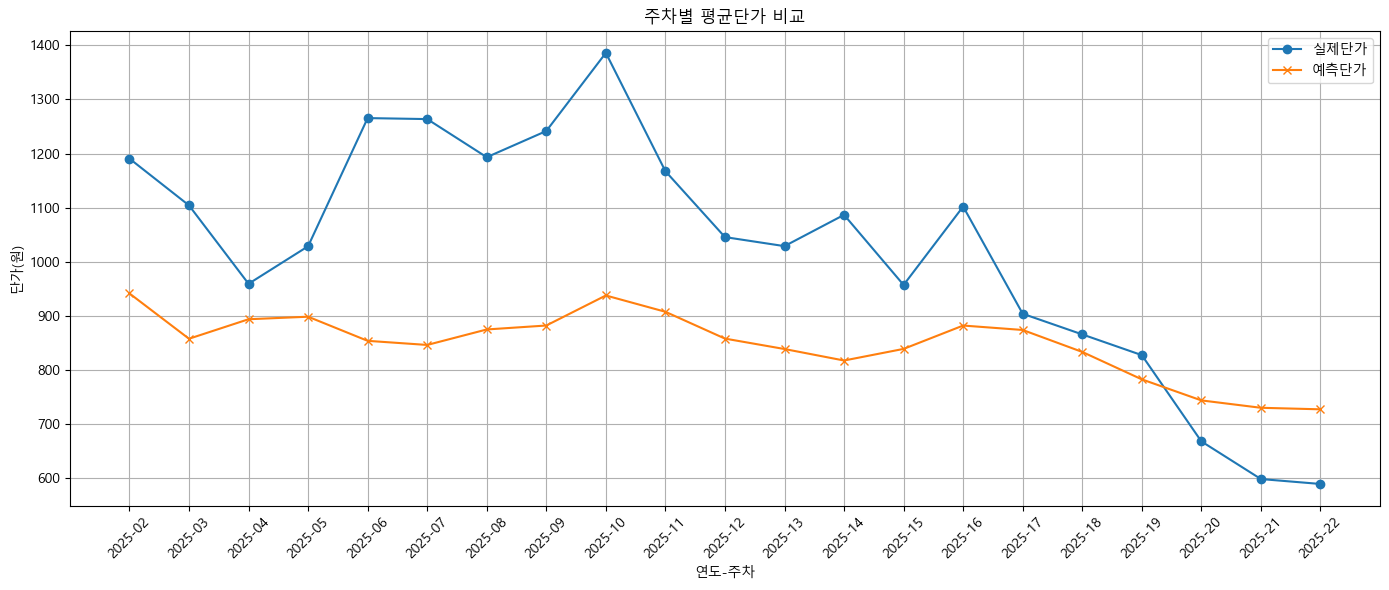

In [ ]:
# 1. 예측 결과와 실제값 결합
df_result = pd.DataFrame({
    'index': y_test.index,
    '실제단가': y_test.values,
    '예측단가': pred
})

# 2. 원본 df에서 'year', 'week' 컬럼만 추출해서 join
df_meta = df[['year', 'week']].reset_index()  # 원본 df에서 날짜 정보 추출
df_result = df_result.merge(df_meta, how='left', on='index')  # index 기준으로 날짜 정보 병합

# 3. 주차별 평균 계산
df_weekly = df_result.groupby(['year', 'week'])[['실제단가', '예측단가']].mean().reset_index()
# 1. year와 week를 문자열로 붙인 새 컬럼 생성 (예: '2025-01')
df_weekly['연도주차'] = df_weekly['year'].astype(str) + '-' + df_weekly['week'].astype(str).str.zfill(2)


# 4. 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(df_weekly['연도주차'], df_weekly['실제단가'], label='실제단가', marker='o')
plt.plot(df_weekly['연도주차'], df_weekly['예측단가'], label='예측단가', marker='x')
plt.title('주차별 평균단가 비교')
plt.xlabel('연도-주차')
plt.ylabel('단가(원)')
plt.xticks(rotation=45)  # x축 라벨이 겹치지 않도록 회전
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()